# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from Multifidelity_support import getModel, kCrossVal, transfBestparam, import_data, normalization, add_noise, MultiFidelity
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf


In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [3]:
# import of the discretization and diffusion values
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [4]:
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = U_HF_test[:, -1, 44,44]
U_HF_test=normalization(U_HF_test)

reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test

In [5]:
noise_stddev1=[0.01,0.005,0.02,0.005]
noise_stddev2=[0.005,0.003,0.01,0.003]

# noise_stddev2 = 0.01       # value?
# noise2 = np.random.normal(0, noise_stddev2, U_HF_test.shape[0])
# noise_stddev3 = 0.005       # value?
# noise3 = np.random.normal(0, noise_stddev3, U_HF_test.shape[0])
# U_HF_noise2 = U_HF_test + noise2
# U_HF_noise3 = U_HF_test + noise3

# noise_stddev4 = 0.02       # value?
# noise4 = np.random.normal(0, noise_stddev4, U_HF_test.shape[0])
# noise_stddev5 = 0.005       # value?
# noise5 = np.random.normal(0, noise_stddev5, U_HF_test.shape[0])
# U_HF_noise4 = U_HF_test + noise4
# U_HF_noise5 = U_HF_test + noise5



# U_HF_test = np.concatenate((U_HF_test, U_HF_noise2,U_HF_noise3,U_HF_noise4,U_HF_noise5),axis=0)


# noise_stddev2 = 0.005       # value?
# noise2 = np.random.normal(0, noise_stddev2, reaction_HF_test.shape[0])
# noise_stddev3 = 0.003       # value?
# noise3 = np.random.normal(0, noise_stddev3, reaction_HF_test.shape[0])
# reaction_HF_noise2 = reaction_HF_test + noise2
# reaction_HF_noise3 = reaction_HF_test + noise3

# noise_stddev4 = 0.01       # value?
# noise4 = np.random.normal(0, noise_stddev4, reaction_HF_test.shape)
# noise_stddev5 = 0.003       # value?
# noise5 = np.random.normal(0, noise_stddev5, reaction_HF_test.shape)
# reaction_HF_noise4 = reaction_HF_test + noise4
# reaction_HF_noise5 = reaction_HF_test + noise5

# reaction_HF_test = np.concatenate((reaction_HF_test, reaction_HF_noise2,reaction_HF_noise3,reaction_HF_noise4,reaction_HF_noise5))
(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)

reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

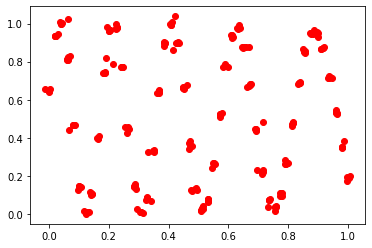

In [6]:

plt.plot(reaction_HF_test[:,0], U_HF_test, "ro", linewidth=1, label="HF model with noise")

plt.show()

In [7]:
print(reaction_HF_test.shape)
print(U_HF_test.shape)

n_HF = np.array([100])
Nlf = np.array([200])

batch_size=[200,100]


(250, 2)
(250,)


In [8]:
U_LF_list = []
U_HF_list = []

Nepo=[7000,8000]

# NepoLF = 7000  # number of epochs for first NN: NN_LF
# NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE



## Neural Network
Cycle on the Discretization and the value of the diffusion 

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


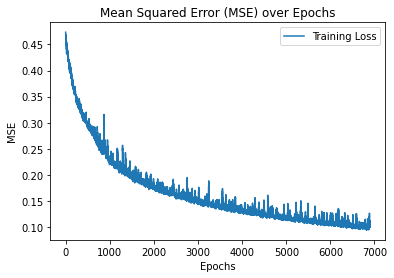

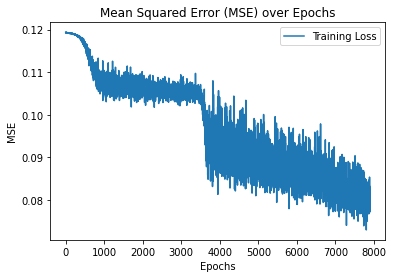

low fidelity NN
Test MSE: 0.009424028766918155
R^2: 0.9243549187843275
Final model
Test MSE: 0.07903390343532296
R^2: 0.3018131595458974


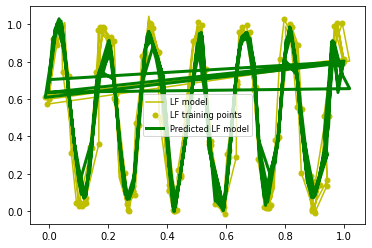

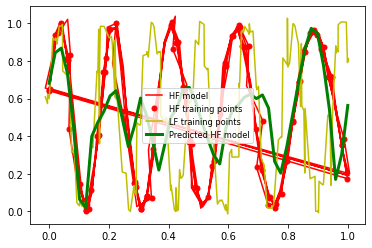

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


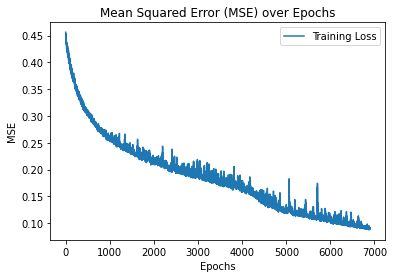

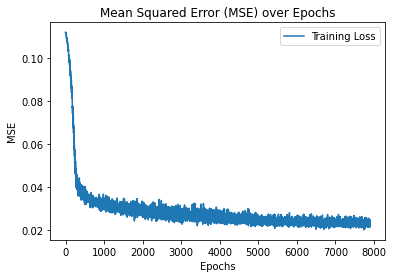

low fidelity NN
Test MSE: 0.0030678724840718513
R^2: 0.9730324478346637
Final model
Test MSE: 0.020016548833627957
R^2: 0.8231734688596954


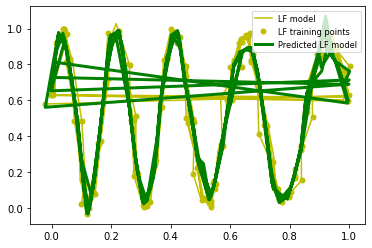

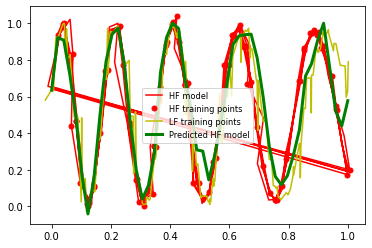

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


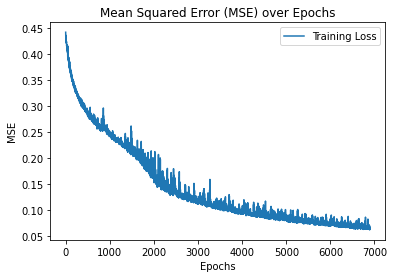

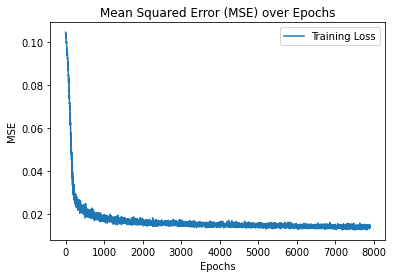

low fidelity NN
Test MSE: 0.009871426511943856
R^2: 0.9161934185693809
Final model
Test MSE: 0.008708438786497045
R^2: 0.9230695043854443


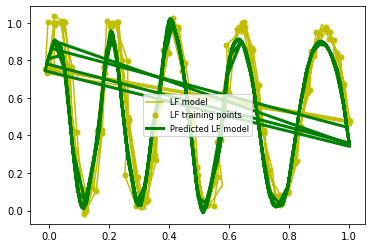

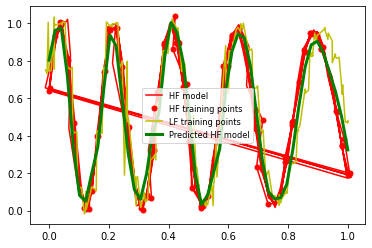

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


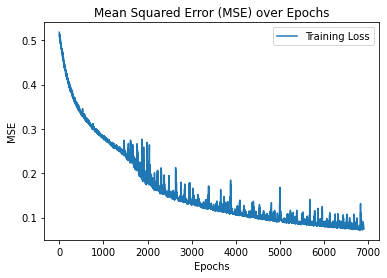

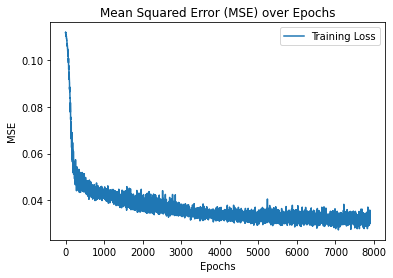

low fidelity NN
Test MSE: 0.023798140251797287
R^2: 0.7944092978115777
Final model
Test MSE: 0.026721287922246664
R^2: 0.7639436902852054


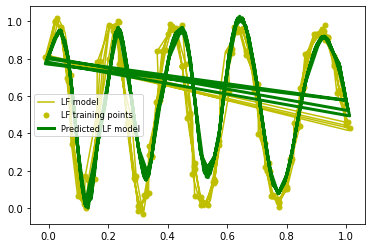

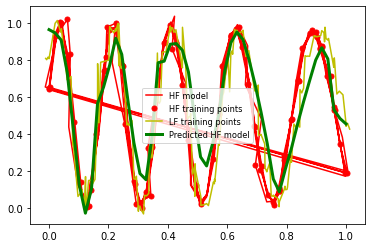

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


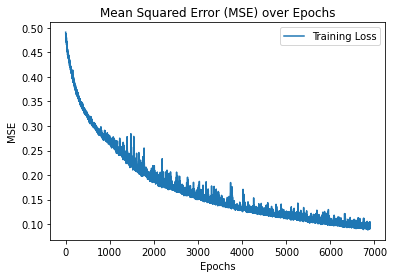

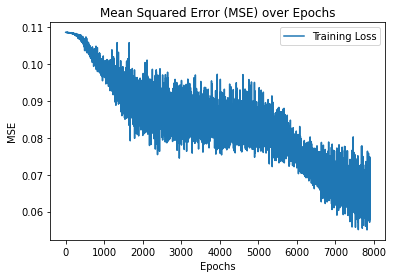

low fidelity NN
Test MSE: 0.01074547292410463
R^2: 0.9137813030276583
Final model
Test MSE: 0.05429754097316192
R^2: 0.5203346041550077


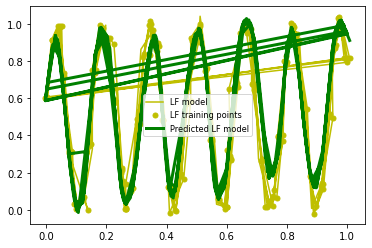

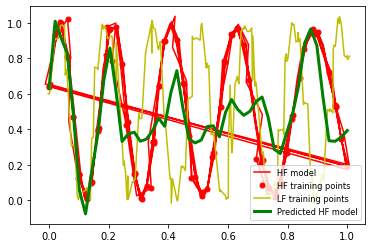

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


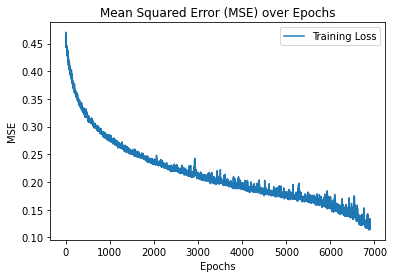

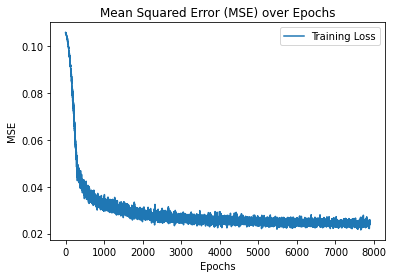

low fidelity NN
Test MSE: 0.0246066914661542
R^2: 0.7827366916675762
Final model
Test MSE: 0.018759933407001834
R^2: 0.8342744308044634


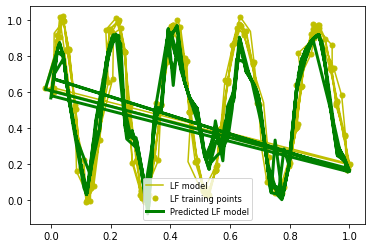

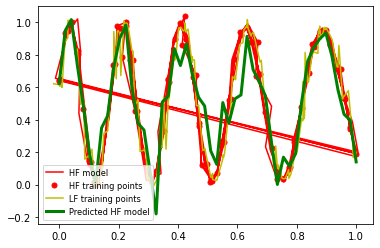

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


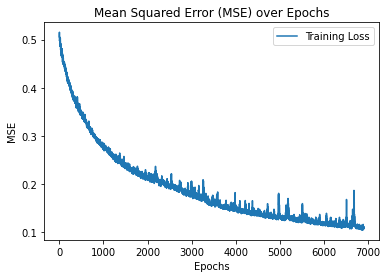

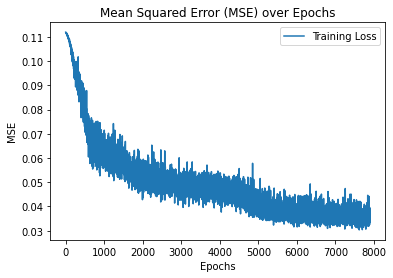

low fidelity NN
Test MSE: 0.017240457262481093
R^2: 0.8533683938594268
Final model
Test MSE: 0.04040372586791865
R^2: 0.6430728019225217


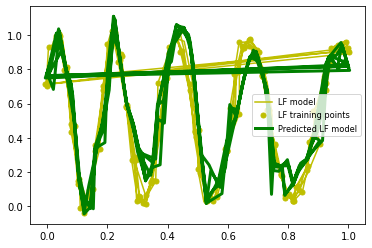

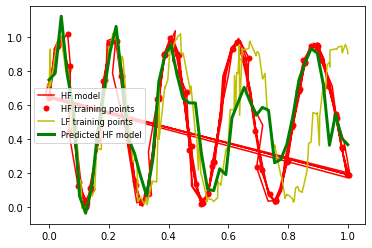

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


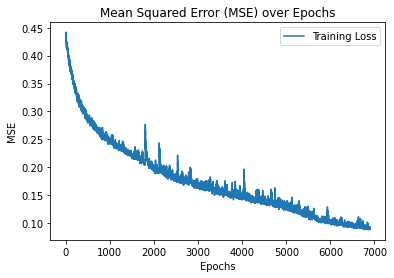

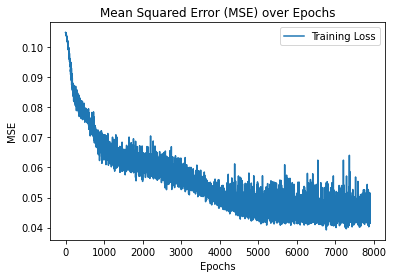

low fidelity NN
Test MSE: 0.0037294539791160515
R^2: 0.9684602462367824
Final model
Test MSE: 0.03726754717083594
R^2: 0.6707778576067258


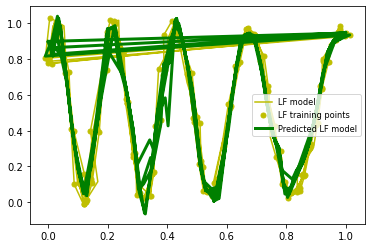

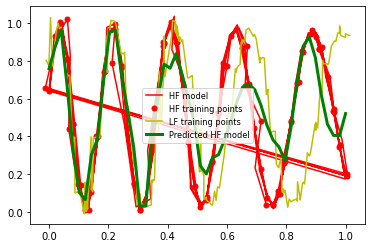

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


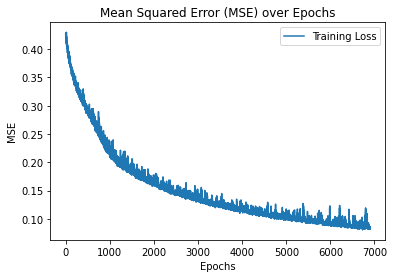

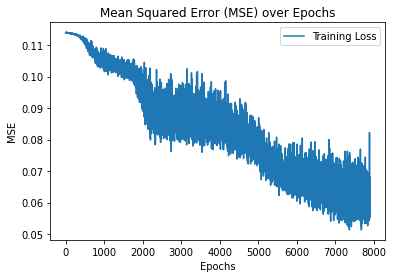

low fidelity NN
Test MSE: 0.0062525970598753255
R^2: 0.949847249985663
Final model
Test MSE: 0.061651246020783555
R^2: 0.45537184931610564


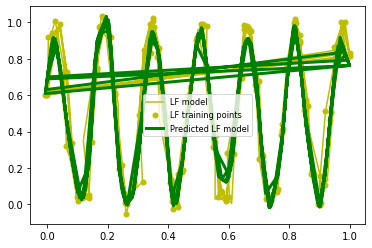

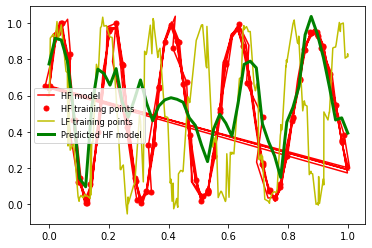

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


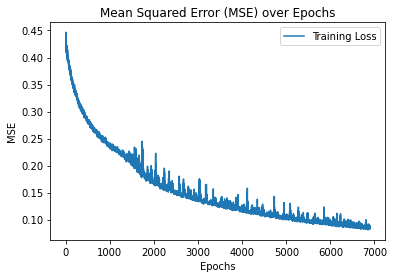

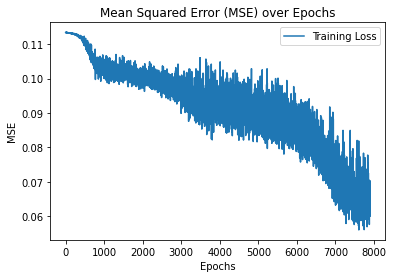

low fidelity NN
Test MSE: 0.011546478343769295
R^2: 0.90719127565196
Final model
Test MSE: 0.06859988127645898
R^2: 0.393987487874333


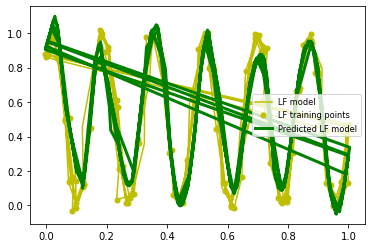

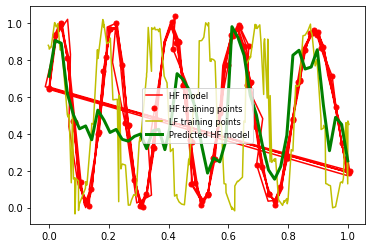

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


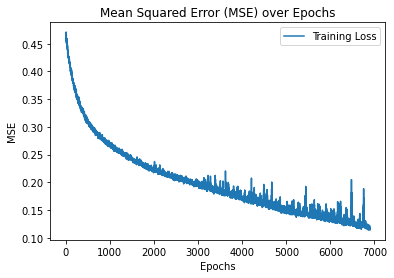

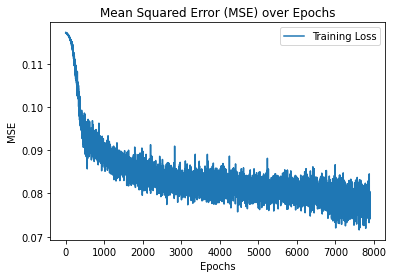

low fidelity NN
Test MSE: 0.019951494144564777
R^2: 0.8436081622882377
Final model
Test MSE: 0.08243795132200071
R^2: 0.271741742907607


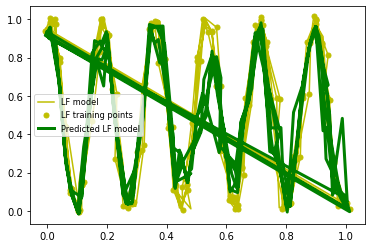

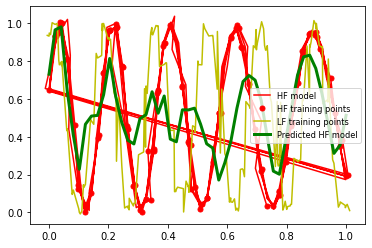

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


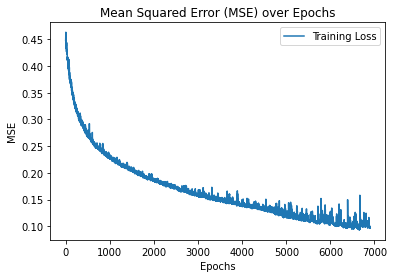

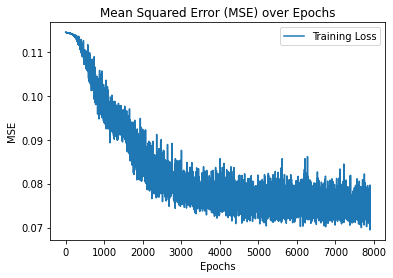

low fidelity NN
Test MSE: 0.024231738265797845
R^2: 0.8005510144450039
Final model
Test MSE: 0.07473528687302967
R^2: 0.3397872110035389


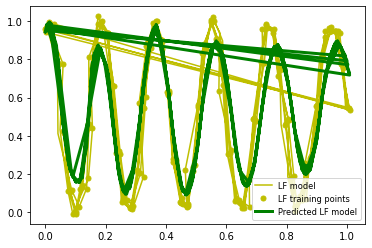

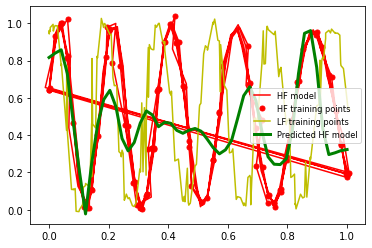

    Discretization  diffusion       R2
0             46.0        0.0  0.19555
1             46.0        0.0  0.30181
2             46.0        5.0  0.82317
3             46.0       75.0  0.92307
4             46.0        1.0  0.76394
5             28.0        0.0  0.52033
6             28.0        5.0  0.83427
7             28.0       75.0  0.64307
8             28.0        1.0  0.67078
9             10.0        0.0  0.45537
10            10.0        5.0  0.39399
11            10.0       75.0  0.27174
12            10.0        1.0  0.33979
    Discretization  diffusion      MSE
0             46.0        0.0  0.09106
1             46.0        0.0  0.07903
2             46.0        5.0  0.02002
3             46.0       75.0  0.00871
4             46.0        1.0  0.02672
5             28.0        0.0  0.05430
6             28.0        5.0  0.01876
7             28.0       75.0  0.04040
8             28.0        1.0  0.03727
9             10.0        0.0  0.06165
10            10.0       

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:317: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:319: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:321: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_9572\1023504480.py:323: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

In [10]:
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
                permutation = np.random.permutation(len(reaction_HF_test))
                ### IMPORT LF DATASETs
                file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
                reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                U_HF = U_HF_test[permutation][0:nhf]
                #print(nhf)

                
                reaction_LF_test = normalization(reaction_LF_test)
                U_LF_test = U_LF_test[
                :,
                - 1,
                int(4*(Discretizations[m]-1)/9),
                int(4*(Discretizations[m]-1)/9)
                ]        
                U_LF_test = normalization(U_LF_test)
                
                reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                U_LF_test_original=U_LF_test
                
                # NOISE
                noise_std1=[0.02,0.01,0.02,0.01]
                noise_std2=[0.01,0.005,0.01,0.005]

                (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)

                
                # noise_stddev2 = 0.02       # value?
                # noise2 = np.random.normal(0, noise_stddev2, U_LF_test.shape)
                # noise_stddev3 = 0.01       # value?
                # noise3 = np.random.normal(0, noise_stddev3, U_LF_test.shape)
                # U_LF_noise2 = U_LF_test + noise2
                # U_LF_noise3 = U_LF_test + noise3
                # noise_stddev4 = 0.02       # value?
                # noise4 = np.random.normal(0, noise_stddev4, U_LF_test.shape)
                # noise_stddev5 = 0.01       # value?
                # noise5 = np.random.normal(0, noise_stddev5, U_LF_test.shape)
                # U_LF_noise4 = U_LF_test + noise4
                # U_LF_noise5 = U_LF_test + noise5
                # noise_stddev6 = 0.02       # value?
                # noise6 = np.random.normal(0, noise_stddev6, U_LF_test.shape)
                # U_LF_noise6 = U_LF_test + noise6
                # noise_stddev7 = 0.01       # value?
                # noise7 = np.random.normal(0, noise_stddev7, U_LF_test.shape)
                # U_LF_noise7 = U_LF_test + noise7

                # U_LF_test = np.concatenate((U_LF_test, U_LF_noise2,U_LF_noise3,U_LF_noise4,U_LF_noise5,U_LF_noise6,U_LF_noise7),axis=0)

                # noise_stddev2 = 0.01       # value?
                # noise2 = np.random.normal(0, noise_stddev2, reaction_LF_test.shape)
                # noise_stddev3 = 0.005       # value?
                # noise3 = np.random.normal(0, noise_stddev3, reaction_LF_test.shape)
                # reaction_LF_noise2 = reaction_LF_test + noise2
                # reaction_LF_noise3 = reaction_LF_test + noise3
                # noise_stddev4 = 0.01       # value?
                # noise4 = np.random.normal(0, noise_stddev4, reaction_LF_test.shape)
                # noise_stddev5 = 0.005       # value?
                # noise5 = np.random.normal(0, noise_stddev5, reaction_LF_test.shape)
                # reaction_LF_noise4 = reaction_LF_test + noise4
                # reaction_LF_noise5 = reaction_LF_test + noise5
                # noise_stddev6 = 0.005       # value?
                # noise6 = np.random.normal(0, noise_stddev6, reaction_LF_test.shape)
                # reaction_LF_noise6 = reaction_LF_test + noise6
                # noise_stddev7 = 0.01       # value?
                # noise7 = np.random.normal(0, noise_stddev7, reaction_LF_test.shape)
                # reaction_LF_noise7 = reaction_LF_test + noise7

                # reaction_LF_test = np.concatenate((reaction_LF_test, reaction_LF_noise2,reaction_LF_noise3,reaction_LF_noise4,reaction_LF_noise5,reaction_LF_noise6,reaction_LF_noise7))
                
                
                # randomization
                permutation = np.random.permutation(len(reaction_LF_test))
                reaction_LF = reaction_LF_test[permutation][0:nlf]
                U_train_LF = U_LF_test[permutation][0:nlf]

                reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                
                
                print(
                f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                )
                
                print(
                f"********************  # Diff: = {diffusion[d]}  ********************"
                )
                
                print(
                f"********************  # NHF: = {nhf}  ********************"
                )
                print(
                f"********************  # NLF: = {nlf}  ********************"
                )

                test_mse_HF_list = []
                test_mse_LF_list = []

                r2_HF_list = []
                r2_LF_list = []
                
                ##########################       FIRST NN: NN_LF     ##########################
                K.clear_session()
                bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
                best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

                # reproducibilty porpuse 
                learning_rate = bestLF_params["lr"]
                optimizer_type = bestLF_params["opt"]

                # Fissa i parametri di ottimizzazione
                if optimizer_type == "Adam":
                    optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Nadam":
                    optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Adamax":
                    optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                else:
                    raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
                #
                names=["LF","2step"]
                params=[bestLF_params, best_params]
                model= MultiFidelity(names,params=params,data_train_LF=reaction_LF,output_train_LF=U_train_LF,data_train_HF=reaction_HF, output_train_HF=U_HF,N=Nepo,n=batch_size,do_HPO=False,verbose=False)
                #model.model_list[0]
                
                # modelLF = getModel(bestLF_params, "LF")  # ann_functions
                # histLF = modelLF.fit(
                #     reaction_LF, U_train_LF,epochs=NepoLF, batch_size=nlf, verbose=0)
                
                
                
                # plt.plot(modelLF.history.history['loss'][100:], label='Training Loss')
                # plt.title('Mean Squared Error (MSE) over Epochs')
                # plt.xlabel('Epochs')
                # plt.ylabel('MSE')
                # plt.legend()
                # plt.show()

                ULF = model.model_list[0].prediction(reaction_LF_test_original)

                # U_LF_list.append(ULF)
                # print("\nLF Model:")
                print("low fidelity NN")
                (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                test_mse_LF_list.append(test_mse_LF)
                #print(f"Test MSE: {test_mse_LF}")

                # r_2 = 1 - np.sum(np.square(U_LF_test_original - ULF[:, 0])) / np.sum(
                #     np.square(U_LF_test_original - np.mean(U_LF_test_original))
                # )
                r2_LF_list.append(r2_LF)
                #print(f"R^2: {r2_LF}")
                
                # start = perf_counter()
                # reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
                # reaction_test_in = np.concatenate(
                #     (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
                # )  # <- TEST INPUT for the second NN: NN_HF

                
                # reaction_test_help_original = modelLF.predict(reaction_HF_test_original)[:, 0]
                # reaction_test_in_original = np.concatenate(
                #     (reaction_HF_test_original, reaction_test_help_original.reshape(-1,1)),axis=1
                # )
                
                
                # reaction_train_help = modelLF.predict(reaction_HF)[
                #     :, 0
                # ]  # f_LF(mu_hf_train)
                input_HF = np.concatenate(
                    (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                )  # <- TRAINING INPUT for the second NN: NN_HF

                input_HF_train = np.concatenate(
                    (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                ) 
                # name = "2step"
                # K.clear_session()
                # best parameters obtained by HPO:

                # best_params = {
                #     "kernel_init": "uniform",
                #     "l2weight": 0.0002588943618918075,
                #     "lr": 0.008365144388542751,
                #     "nodes": 16.0,
                #     "opt": "Adam",
                # }
   #             best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}
                
                # # reproducibilty porpuse 
                # learning_rate = best_params["lr"]
                # optimizer_type = best_params["opt"]

                # # Fissa i parametri di ottimizzazione
                # if optimizer_type == "Adam":
                #     optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                # elif optimizer_type == "Nadam":
                #     optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                # elif optimizer_type == "Adamax":
                #     optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                # else:
                #     raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
                # #
                
                
                
                # finalModel = getModel(
                #     best_params, name
                # )  # final model chosen according to the best paramters
                # hist = finalModel.fit(
                #     reaction_final,
                #     U_HF,
                #     validation_data=(reaction_test_in_original, U_HF_test_original),
                #     epochs=NepoHF,
                #     batch_size=nhf,
                #     verbose=0,
                #     validation_freq=20,
                # )
            
                # plt.plot(model.model_list[1].history.history['loss'][100:], label='Training Loss')
                # #plt.plot(finalModel.history.history['loss'][50:], label='Training Loss')
                # plt.title('Mean Squared Error (MSE) over Epochs (final Model)')
                # plt.xlabel('Epochs')
                # plt.ylabel('MSE')
                # plt.legend()
                # plt.show()

                # UHF = finalModel.predict(reaction_test_in_original)
                # U_HF_list.append(UHF)

                # stop = perf_counter()
                # elapsed = stop - start
                # print("Elapsed time: ", elapsed)
                # print("\nHF Model:")
                print("Final model")
                (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_HF_test_original)

                
                test_mse_HF_list.append(test_mse_HF)
                #print(f"Test MSE: {test_mse_HF}")

                # r2_HF = 1 - np.sum(np.square(U_HF_test_original - UHF[:, 0])) / np.sum(
                #     np.square(U_HF_test_original - np.mean(U_HF_test_original))
                # )
                r2_HF_list.append(r2_HF)
                #print(f"R^2: {r2_HF}")
                
                
                plt.figure()
                plt.plot(
                reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
                )
                plt.plot(
                reaction_LF[:, 0],
                U_train_LF,
                "yo",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                reaction_LF_test[:, 0],
                model.model_list[0].prediction(reaction_LF_test),
                "g-",
                linewidth=3,
                label="Predicted LF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()
                
                plt.figure()
                plt.plot(
                reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model"
                )
                plt.plot(
                input_HF_train[:, 0],
                U_HF,
                "ro",
                markersize=5,
                label="HF training points",
                )
                
                
                order=np.argsort(reaction_LF[:,0])
                
                plt.plot(
                reaction_LF[order,0],
                U_train_LF[order],
                "y-",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                input_HF[:, 0],
                model.model_list[1].prediction(input_HF),
                "g-",
                linewidth=3,
                label="Predicted HF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()

                #r2_LF_df[[str(Discretizations[m]),diffusion[d]]] = r2_LF_list
                #r2_HF_df[[str(Discretizations[m]),diffusion[d]]] = r2_HF_list
                #mse_LF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_LF_list
                #mse_HF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_HF_list
                
                
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                r2_LF_df = r2_LF_df.append(new, ignore_index=True)      
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                r2_HF_df = r2_HF_df.append(new, ignore_index=True)  
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                mse_LF_df = mse_LF_df.append(new, ignore_index=True) 
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                mse_HF_df = mse_HF_df.append(new, ignore_index=True)
                
                # if len(r2_HF_list[:-1])>0 and r2_HF_list[-1]<max(r2_HF_list[:-1]):
                # #     save_model(finalModel,"finalModel2NN.h5")
                
                
                ##  SALVATAGGIO CON NUOVA CLASSE?
                
                if not r2_HF_list[:-1]:
                    model.save
                elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                    model.save
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



## Save the output

In [ ]:
os.makedirs("MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class")

r2_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class'